In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROCESSED_DIR = Path("../data/processed")
MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("./outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

data = joblib.load(
    PROCESSED_DIR / "processed_data.joblib"
)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print("Processed data loaded successfully!")

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Processed data loaded successfully!
Training: (198608, 30)
Validation: (42559, 30)
Test: (42559, 30)


In [3]:
random_forest_model = joblib.load(
    MODEL_DIR / "random_forest_smote.joblib"
)

print("Random Forest model loaded successfully.")

Random Forest model loaded successfully.


In [4]:
feature_names = X_train.columns.tolist()

print("Number of features:", len(feature_names))
print("\nFeatures:")
print(feature_names)

Number of features: 30

Features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [5]:
explainer = shap.TreeExplainer(
    random_forest_model
)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [6]:
SHAP_SAMPLE_SIZE = 1000

X_shap = X_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (1000, 30)


In [7]:
print("Calculating SHAP values...")

shap_values = explainer.shap_values(
    X_shap
)

print("SHAP calculation completed!")

Calculating SHAP values...
SHAP calculation completed!


In [8]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP arrays:", len(shap_values))
    for i, value in enumerate(shap_values):
        print(f"SHAP array {i} shape:", value.shape)
else:
    print("SHAP shape:", shap_values.shape)

<class 'numpy.ndarray'>
SHAP shape: (1000, 30, 2)


In [9]:
shap_values = explainer.shap_values(X_shap)

In [10]:
SHAP_SAMPLE_SIZE = 200

X_shap = X_test.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (200, 30)


In [11]:
print("Calculating SHAP values...")

shap_values = explainer.shap_values(X_shap)

print("SHAP calculation completed!")

Calculating SHAP values...
SHAP calculation completed!


In [12]:
print("SHAP sample shape:", X_shap.shape)
print("SHAP calculation completed!")

SHAP sample shape: (200, 30)
SHAP calculation completed!


In [13]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP arrays:", len(shap_values))
    for i, value in enumerate(shap_values):
        print(f"SHAP array {i} shape:", value.shape)
else:
    print("SHAP shape:", shap_values.shape)

<class 'numpy.ndarray'>
SHAP shape: (200, 30, 2)


In [14]:
# Extract SHAP values for the fraud class (Class = 1)
shap_values_fraud = shap_values[:, :, 1]

print("Fraud SHAP shape:", shap_values_fraud.shape)

Fraud SHAP shape: (200, 30)


In [15]:
# Create a SHAP Explanation object for the fraud class
shap_explanation = shap.Explanation(
    values=shap_values_fraud,
    data=X_shap,
    feature_names=feature_names
)

print("SHAP explanation created successfully!")

SHAP explanation created successfully!


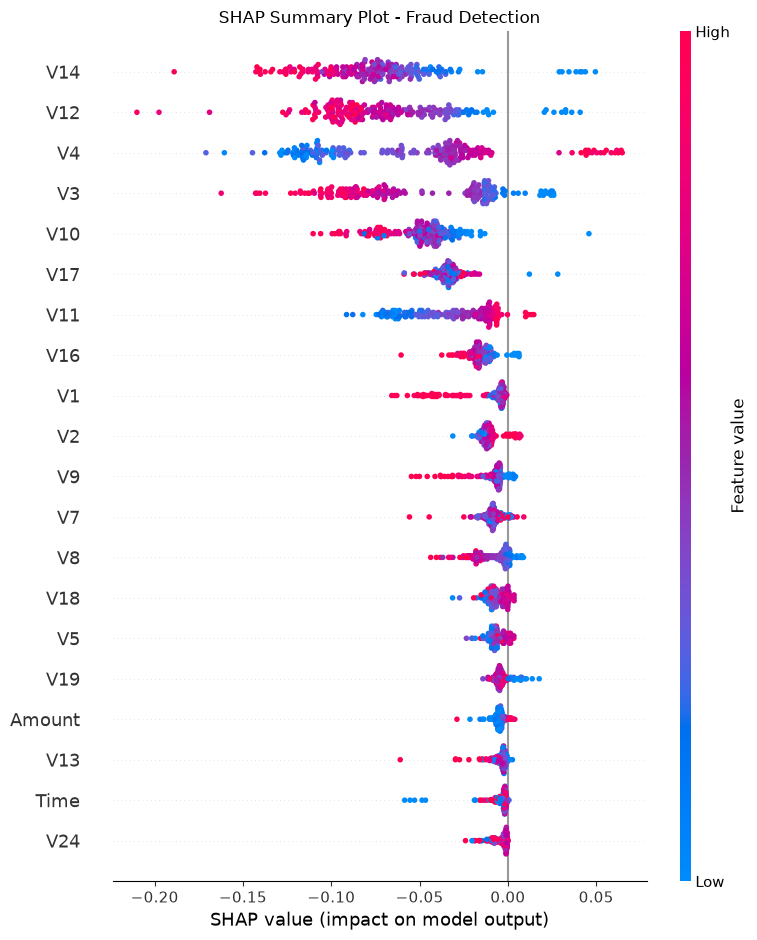

In [16]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_fraud,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot - Fraud Detection")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

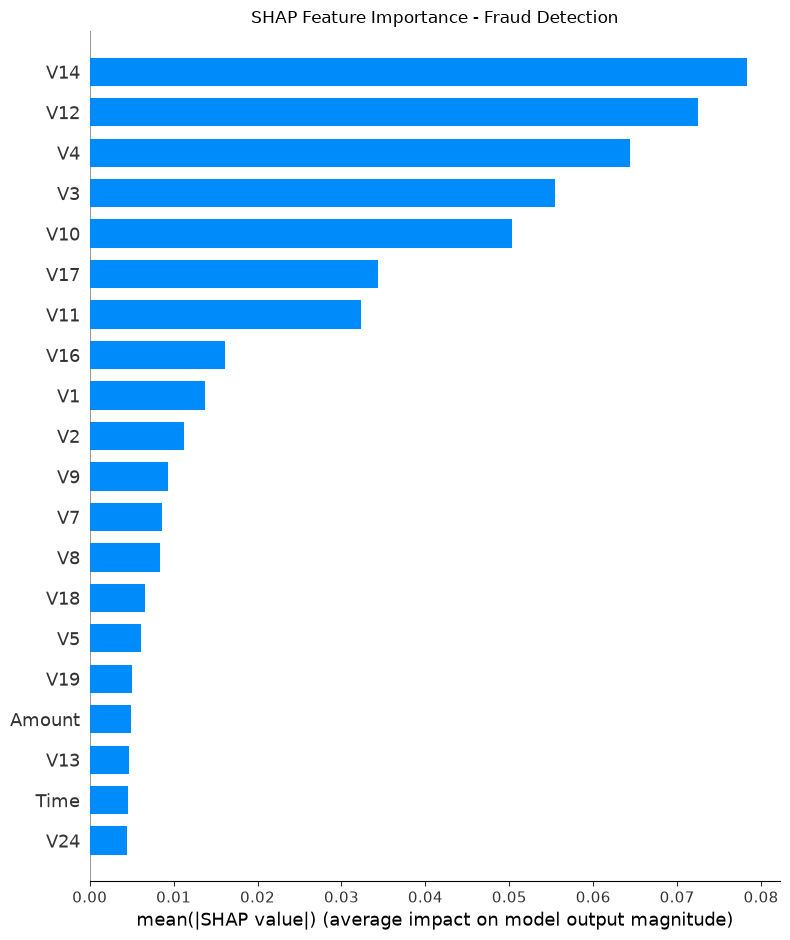

In [17]:
# SHAP Feature Importance Bar Chart

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_fraud,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance - Fraud Detection")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# Select one transaction for local explanation

transaction_index = 0

single_transaction = X_shap.iloc[[transaction_index]]

print("Transaction shape:", single_transaction.shape)
print("Actual class:", y_test.loc[single_transaction.index].iloc[0])

Transaction shape: (1, 30)
Actual class: 0


In [19]:
# Get model prediction and probability

prediction = random_forest_model.predict(single_transaction)[0]
probability = random_forest_model.predict_proba(single_transaction)[0]

print("Predicted class:", prediction)
print("Legitimate probability:", probability[0])
print("Fraud probability:", probability[1])

Predicted class: 0
Legitimate probability: 1.0
Fraud probability: 0.0


In [20]:
# Calculate SHAP values for the selected transaction

single_shap_values = explainer.shap_values(single_transaction)

print("SHAP output type:", type(single_shap_values))

if isinstance(single_shap_values, list):
    single_shap_fraud = single_shap_values[1][0]
else:
    single_shap_fraud = single_shap_values[0, :, 1]

print("Single transaction SHAP shape:", single_shap_fraud.shape)

SHAP output type: <class 'numpy.ndarray'>
Single transaction SHAP shape: (30,)


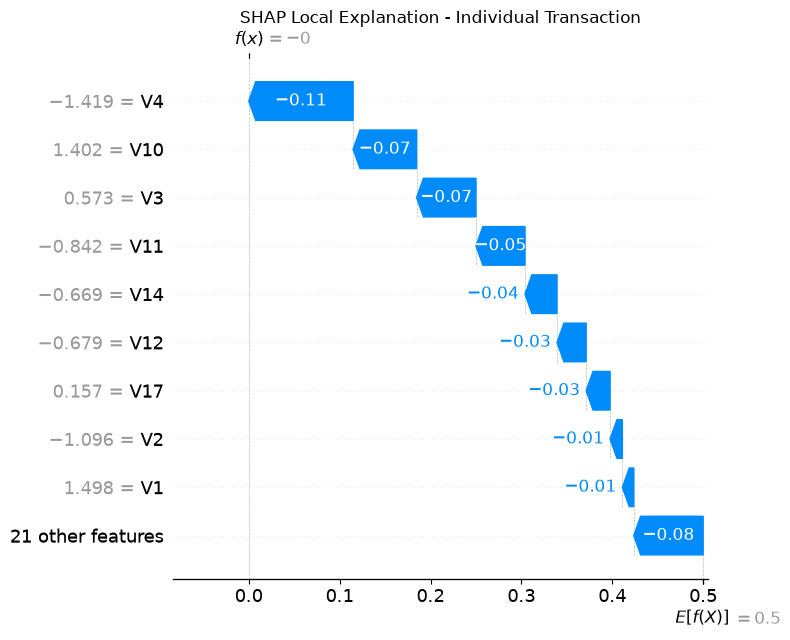

In [21]:
# Local SHAP explanation for the selected transaction

plt.figure(figsize=(10, 8))

shap.waterfall_plot(
    shap.Explanation(
        values=single_shap_fraud,
        base_values=explainer.expected_value[1],
        data=single_transaction.iloc[0].values,
        feature_names=feature_names
    ),
    show=False
)

plt.title("SHAP Local Explanation - Individual Transaction")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "shap_local_explanation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Generate a human-readable explanation

top_indices = np.argsort(np.abs(single_shap_fraud))[::-1][:5]

print("===== FRAUDGUARD AI EXPLANATION =====")
print()

if prediction == 1:
    print("Prediction: FRAUD")
else:
    print("Prediction: LEGITIMATE")

print(f"Fraud probability: {probability[1]:.4f}")
print()

print("Top contributing features:")

for idx in top_indices:
    feature = feature_names[idx]
    value = single_transaction.iloc[0][feature]
    contribution = single_shap_fraud[idx]

    direction = "increased" if contribution > 0 else "decreased"

    print(
        f"- {feature}: value={value:.4f}, "
        f"SHAP={contribution:.4f}, "
        f"{direction} the fraud prediction"
    )

===== FRAUDGUARD AI EXPLANATION =====

Prediction: LEGITIMATE
Fraud probability: 0.0000

Top contributing features:
- V4: value=-1.4193, SHAP=-0.1148, decreased the fraud prediction
- V10: value=1.4019, SHAP=-0.0698, decreased the fraud prediction
- V3: value=0.5733, SHAP=-0.0654, decreased the fraud prediction
- V11: value=-0.8418, SHAP=-0.0539, decreased the fraud prediction
- V14: value=-0.6685, SHAP=-0.0352, decreased the fraud prediction


In [1]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

sample = df.iloc[0]

print(sample.to_dict())

{'Time': 0.0, 'V1': -1.3598071336738, 'V2': -0.0727811733098497, 'V3': 2.53634673796914, 'V4': 1.37815522427443, 'V5': -0.338320769942518, 'V6': 0.462387777762292, 'V7': 0.239598554061257, 'V8': 0.0986979012610507, 'V9': 0.363786969611213, 'V10': 0.0907941719789316, 'V11': -0.551599533260813, 'V12': -0.617800855762348, 'V13': -0.991389847235408, 'V14': -0.311169353699879, 'V15': 1.46817697209427, 'V16': -0.470400525259478, 'V17': 0.207971241929242, 'V18': 0.0257905801985591, 'V19': 0.403992960255733, 'V20': 0.251412098239705, 'V21': -0.018306777944153, 'V22': 0.277837575558899, 'V23': -0.110473910188767, 'V24': 0.0669280749146731, 'V25': 0.128539358273528, 'V26': -0.189114843888824, 'V27': 0.133558376740387, 'V28': -0.0210530534538215, 'Amount': 149.62, 'Class': 0.0}


In [2]:
df_original = pd.read_csv("../data/creditcard.csv")

sample = df_original.iloc[0]

print(sample)

Time        0.000000
V1         -1.359807
V2         -0.072781
V3          2.536347
V4          1.378155
V5         -0.338321
V6          0.462388
V7          0.239599
V8          0.098698
V9          0.363787
V10         0.090794
V11        -0.551600
V12        -0.617801
V13        -0.991390
V14        -0.311169
V15         1.468177
V16        -0.470401
V17         0.207971
V18         0.025791
V19         0.403993
V20         0.251412
V21        -0.018307
V22         0.277838
V23        -0.110474
V24         0.066928
V25         0.128539
V26        -0.189115
V27         0.133558
V28        -0.021053
Amount    149.620000
Class       0.000000
Name: 0, dtype: float64
